# TP Noté Informatique Quantique (Polytech Paris-Saclay 2025/2026)

**Mathieu WAHARTE**  

## Consignes
- Tout ce dont vous avez besoin pour programmer durant cet examen est importé dans la cellule ci-dessous, pensez bien à l'exécuter !
- Les 3 exercices sont indépendants.
- Vous avez le droit aux documents, notamment les sujets et corrigés des TP.
- Vous avez aussi accès à internet, **MAIS** l'objectif est d'évaluer vos acquis et capacités de programmation. Vous avez le droit de faire des recherches sur internet, d'utiliser l'IA si vous le souhaitez comme un outil de réflexion, mais tout code rédigé par IA (preuve ou suspicion) sera pénalisé.
- C'est un examen **INDIVIDUEL**, vous ne pouvez donc pas communiquer avec vos camarades. Deux copies identiques seront sanctionnées sans discernement.
- A la fin du TP, envoyer ce notebook en le renommant "examen_TP_prenom_nom.ipynb" à l'adresse mail : oceanekoska@gmail.com

Bonne chance à vous, j'espère que vous prendrez un peu de fun avec ce sujet.

## Code à exécuter

In [1]:
# Décommenter la ligne ci-dessous si myqlm n'est pas installé
%pip install myqlm

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qat.lang import QRoutine, H, CNOT, CCNOT, RY, Z, X, Program
from qat.qpus import get_default_qpu

qpu = get_default_qpu()

def display_result(circuit, nbshots=0, idx=None):
    result = qpu.submit(circuit.to_job(nbshots=nbshots, qubits=idx))
    if nbshots:
        tmp = {}
        for sample in result:
            state = sample.state
            if not state in tmp:
                tmp[state] = 0.
            tmp[sample.state] += sample.probability
        for state, proba in tmp.items():
            print("Etat %s: probabilité %s" % (state, proba))
    else:
        for sample in result:
            print("Etat %s: probabilité %s, amplitude %s" % (sample.state, sample.probability, sample.amplitude))

def histogram(func, nb_qubits):
    val = np.zeros(1 << nb_qubits)
    N = 500
    for _ in range(N):
        rout = func(nb_qubits).to_circ()
        result = qpu.submit(rout.to_job(nbshots=1))
        val[result[0].state.int]+=1
    
    if nb_qubits == 3:
        labels_binaires = [f"{format(i, '03b')}" for i in range(8)]
    else:
        labels_binaires = [f"{format(i, '03b')}" for i in range(1 << nb_qubits)]
    plt.xticks(range(8), labels_binaires, rotation=45)
    
    plt.bar(range(1 << nb_qubits), val/ N)
    plt.show()

def one_shot(prog):
    result = qpu.submit(prog.to_circ().to_job(nbshots=1))
    result = result[0].state.bitstring
    liste = []
    for b in result:
        liste.append(int(b))
    return liste

# Début du sujet

Vous voilà sur la mer avec votre équipage, et une carte au trésor. Le quotidien d'un pirate en somme. Votre avantage par rapport aux autres pirates de la région ? Un navire totalement équipé de la technologie Quantum Navigation dernier cri, un luxe au XVIIIème siècle. Ce navire, vous en êtes fier, il vous ammène à bon port, contre vents et marées depuis plusieures années et vous l'avez nommé :


**Nom du navire** (1 point bonus, c'est gratuit) : Wave Collapser

# Exercice 1 : Emplacement du trésor (4/20)

Sur la carte que vous tenez entre vos mains, il n'y a pas une simple croix où se situe le trésor tant convoité. En fait, il y a deux schémas, deux circuits quantiques, qui indiqueraient les coordonnées géographiques du trésor. Par chance, vous avez à votre disposition un lecteur de circuits quantiques qui vous traduira instantanément tout circuit en une valeur. Le premier circuit, donnant la coordonnée en x est le suivant

<center>
<img src="img/circuit_x.png">
</center>

**Question 1.1**: Implémenter le circuit ci-dessus et afficher la coordonnée x du trésor à l'aide de la fonction *display_result(circuit)*.

In [5]:
def tresor_x():
  rout = QRoutine()
  q = rout.new_wires(4)
  
  X(q[0])
  
  CNOT(q[0], q[2])
  
  CCNOT(q[0], q[2], q[1])
  
  X(q[1])
  CNOT(q[2], q[3])
  
  return rout

tresor_x().display()
display_result(tresor_x())

Etat |1011>: probabilité 1.0, amplitude (1+0j)


Coordonnée X : 1011

Le second circuit, pour généré la coordonnée en y, est le suivant

<center>
<img src="img/circuit_y.png">
</center>

**Question 1.2**: Implémenter le circuit ci-dessus et afficher les coordonnées y possibles du trésor à l'aide de la fonction *display_result(circuit)*. La seule coordonnée valide est celle ayant une amplitude positive.

In [6]:
def tresor_y():
  rout = QRoutine()
  q = rout.new_wires(4)
  
  X(q[1])
  
  CNOT(q[1], q[2])
  
  Z(q[2])
  
  CNOT(q[2], q[0])
  
  H(q[0])
  X(q[1])
  
  CNOT(q[0], q[3])
  
  H(q[3])
  
  return rout

tresor_y().display()
display_result(tresor_y())

Etat |0010>: probabilité 0.2499999999999999, amplitude (-0.4999999999999999+0j)
Etat |0011>: probabilité 0.2499999999999999, amplitude (-0.4999999999999999+0j)
Etat |1010>: probabilité 0.2499999999999999, amplitude (0.4999999999999999+0j)
Etat |1011>: probabilité 0.2499999999999999, amplitude (-0.4999999999999999+0j)


Coordonée Y : 1010 (les autres ont la même probabilité mais des amplitudes négatives)

# Exercice 2 : La boussole (8/20)

Maintenant que vous avez un cap, votre équipage est en route pour trouver le trésor. Pour vous orienter vous utilisez une boussole quantique comme celle ci-dessous.
<center>
<img src="img/boussole.png", width=400px>
</center>

Votre boussole est représentée par un qubit dans l'état $\alpha |0\rangle + \beta |1\rangle$, où $|0\rangle$ représente le Nord et $|1\rangle$ le Sud. Si on prend $\alpha$ et $\beta$ réels, alors sur la boussole on a l'Est qui correspond à l'état 
$$
|+\rangle = \frac{1}{\sqrt{2}} ( |0\rangle + |1\rangle )
$$
et l'Ouest à l'état
$$
|-\rangle = \frac{1}{\sqrt{2}} ( |0\rangle - |1\rangle )
$$


Vous arriviez bien à vous orienter jusqu'à ce que vous entriez une zone avec des pertubations électromagnétiques imprévisibles. Impossible de garder le cap avec une simple boussole qui peut donner une information erronée. Pour remédier à ce problème, vous équipez deux de vos moussaillons d'une boussole similaire à la votre, avec trois boussoles vous serez en mesure de maintenir le cap.

## Initialisation

Juste avant de rentrer dans la zone de perturbation, il faut synchroniser les trois boussoles sur la même valeur, celle indiquée par votre boussole. Pour rappel, votre boussole est représentée par un qubit dans l'état $\alpha |0\rangle + \beta |1\rangle$, état préparé grâce à la routine quantique *initialisation*. Après synchronisation, les trois boussoles sont dans l'état $\alpha |000\rangle + \beta |111\rangle$.

**Question 2.1** Implémenter la routine quantique *initialisation* qui initialise votre boussole dans l'état $\alpha |0\rangle + \beta |1\rangle$, avec $\alpha$ et $\beta$ réels (on pourra utiliser une porte RY).

In [26]:
alpha = np.sqrt(1/4)
beta = -np.sqrt(3/4)

print("alpha = ", alpha, "beta = ", beta)

# Routine d'initialisation de la boussole du capitaine
def initialisation():
  rout = QRoutine()
  q = rout.new_wires(1)
  
  RY(2 * np.arccos(alpha))(q[0]) # car cos(arcos(alpha)) = alpha et sin(arcos(alpha)) = |beta|
  
  return rout


alpha =  0.5 beta =  -0.8660254037844386


**Question 2.2** : Vérifier que la routine initialisation encode bien le bon état à l'aide de la fonction *display_result*.

*Note : la phase globale n'a pas d'impact, obtenir $-(\alpha |0\rangle + \beta |1\rangle)$ est équivalent à $\alpha |0\rangle + \beta |1\rangle$*

In [27]:
display_result(initialisation(), nbshots=1000)

Etat |1>: probabilité 0.748
Etat |0>: probabilité 0.252


**Question 2.3** : Implémenter la routine quantique *synchronisation* qui initialise votre boussole et intrique son état avec les autres boussoles.

In [32]:
def synchronisation(nb_qubits):
  rout = QRoutine()
  q = rout.new_wires(nb_qubits)
  
  # Initialise le qubit du capitaine : alpha|0> + beta|1>
  initialisation()(q[0])
  
  # Propage l'état aux autres boussoles via CNOT
  for i in range(1, nb_qubits):
    CNOT(q[0], q[i])
  
  return rout


**Question 2.4** Vérifier que l'état obtenu en sortie est correct. 

In [33]:
synchronisation(3).display()
display_result(synchronisation(3), nbshots=1000)

Etat |000>: probabilité 0.259
Etat |111>: probabilité 0.741


## Partie A : Inversion polaire

Le premier problème que cause la tempête électromagnétique est une inversion polaire. Le sud ($|1\rangle$) et le nord ($|0\rangle$) peuvent se retrouver inversés, avec une probabilité $p=0.05$. Heureusement, avec trois boussoles vous êtes en mesure de contourner le problème. La fonction ci-dessous correspond à l'inversion polaire.

In [40]:
def inversion_polaire(nb_qubits):
  rout = QRoutine()
  qubits = rout.new_wires(nb_qubits)

  p = 0.05
  for q in qubits:
    if np.random.rand() < p:
      X(q)
  
  return rout     

**Question 2.5**: Implémenter la routine *etape_A* qui correspond à l'étape de synchronisation puis l'inversion polaire

In [41]:
def etape_A(nb_qubits):
  rout = QRoutine()
  q = rout.new_wires(nb_qubits)
  
  synchronisation(nb_qubits)(q)
  inversion_polaire(nb_qubits)(q)

  return  rout

Le code ci-dessous permet d'afficher l'histograme des probabilités d'obtenir chaque état en sortie de l'inversion polaire.

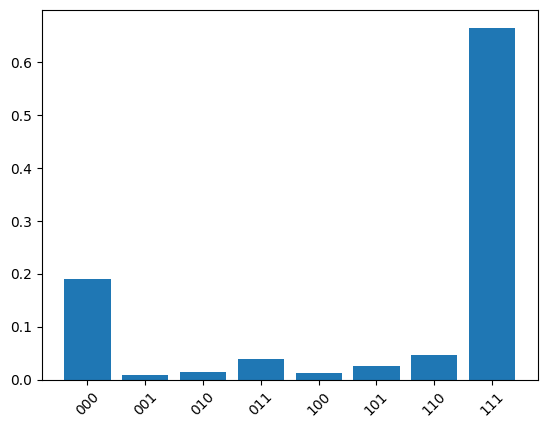

In [42]:
histogram(etape_A, 3)

**Question 2.6** : Expliquer à quoi devrait ressembler l'histogramme si **AUCUNE** pertubation n'était à signaler dans la région.

S'il n'y avait aucune perturbations, les états 001, 010, 011, 100, 101 et 110 auraient une probabilité de 0 et on aurait les probabilités de l'initialisation pour 000 et 111.

Pour rappel, la probabilité qu'une boussole se retrouve affectée par l'inversion polaire est de $p=0.05$. Avec 3 boussoles différentes, on peut espérer que la majorité indique quand même le bon résultat, puisqu'il faudrait qu'au moins 2 d'entres elles aient subit l'inversion.

**Question 2.7** : Quelle est la probabilité que la majorité des boussoles se trompent ? Cela vous paraît-il satisfaisant ?

La probabilité que la majorité des boussoles se trompent est de $\mathbb{P}(2\text{ boussoles affectées}) + \mathbb{P}(3\text{ boussoles affectées}) = 3 \cdot p^2 \cdot (1-p) + p^3 = 0.00725 = 0.725\%$. Je trouve que c'est satisfaisant pour une seule perturbation, attention au cas où l'on rencotre plusieurs perturbations ou qu'elles sont plus sévères.  

## Partie B : Pertubation de phase

La tempête électromagnétique peut causer un second problème au niveau des boussoles quantiques, elles peuvent aussi impacter la phase relative de l'état. En effet l'état $\alpha |0\rangle + \beta |1\rangle$ peut malencontreusement devenir $\alpha |0\rangle - \beta |1\rangle$. Ceci est indétectable par une mesure directe de Nord $|0\rangle$ ou Sud $|1\rangle$, mais a un fort impact pour s'orienter vers l'Est $|+\rangle$ et l'Ouest $|-\rangle$. Comme pour ce problème on ne peut pas travailler dans la base Nord $|0\rangle$, Sud $|1\rangle$, on va d'abord changer de base pour celle Est $|+\rangle$, Ouest $|-\rangle$.

Pour rappel, on a les égalités suivantes: 
$$
|+\rangle = \frac{1}{\sqrt{2}} ( |0\rangle + |1\rangle )
$$
et 
$$
|-\rangle = \frac{1}{\sqrt{2}} ( |0\rangle - |1\rangle )
$$

**Question 2.8** Quelle porte quantique permet de passer d'un qubit dans un état de la base $(|0\rangle, |1\rangle)$ à la base $(|+\rangle, |-\rangle)$ ?

La porte quantique qui permet de passer de $\ket{0}$ et $\ket{1}$ a $\ket{+}$ et $\ket{-}$ est la porte de Hadamar $H$.

**Question 2.9** : Implémenter la routine quantique *changement_base(nb_qubits)* qui effectue ce changement de base sur chaque qubit.

In [49]:
def changement_base(nb_qubits):
  rout = QRoutine()
  q = rout.new_wires(nb_qubits)
  
  for i in range(nb_qubits):
    H(q[i])

  return rout

La fonction quantique *perturbation_phase* réalise la perturbation sur la phase avec une probabilité $p=0.2$.

In [50]:
def perturbation_phase(nb_qubits):
  rout = QRoutine()
  qubits = rout.new_wires(nb_qubits)

  p = 0.2
  for q in qubits:
    if np.random.rand() < p:
      Z(q)
  
  return rout     

**Question 2.10** : Implémenter la routine quantique *etape_B* qui réalise la synchronisation puis la pertubation (en pensant aux changements de base)

In [53]:
def etape_B(nb_qubits):
  rout = QRoutine()
  qubits = rout.new_wires(nb_qubits)
  
  synchronisation(nb_qubits)(qubits)
  changement_base(nb_qubits)(qubits)
  perturbation_phase(nb_qubits)(qubits)
  changement_base(nb_qubits)(qubits)
  
  return rout

etape_B(3).display()

L'appel à la fonction histogram ci-dessous affiche l'histogramme des probabilités en sortie de l'*etape_B*.

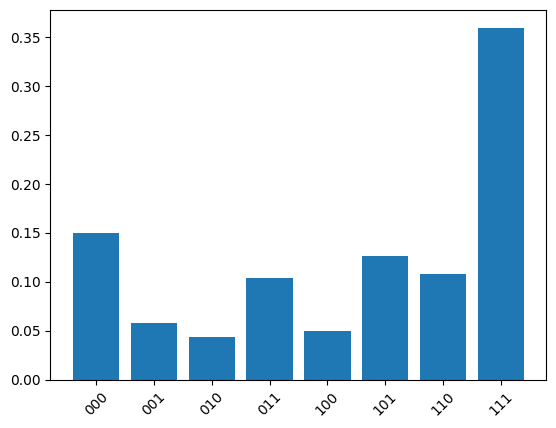

In [54]:
histogram(etape_B, 3)

La probabilité que la tempête électromagnétique inflige une pertubation de phase est de $p=0.2$.

**Question 2.11** : Combien de boussoles sont nécessaires pour être sûr à plus de 99% de retrouver le bon résultat ?

Pour modéliser les perturbations, on note $X\sim\mathcal{B}(n,0.2)$, où $X$ est le nombre de boussoles affectées.  
La probabilité d’avoir exactement $k$ boussoles affectées vaut $\displaystyle{\mathbb{P}(X=k)=\binom{n}{k}(0.2)^k(0.8)^{n-k}}$.  
Le vote majoritaire échoue si plus de la moitié des boussoles sont affectées, donc $\displaystyle{P_{\text{err}}(n)=\sum_{k=\lfloor n/2\rfloor+1}^{n}\binom{n}{k}(0.2)^k(0.8)^{n-k}}$.  
On cherche $P_{\text{err}}(n)<0.01$ (fiabilité $>99\%$).  
On trouve $P_{\text{err}}(11)\approx 0.01165$ et $P_{\text{err}}(13)\approx 0.00700$.  
Donc le plus petit nombre de boussoles satisfaisant la contrainte est $n=13$.  

&nbsp;  
On peut le vérifier empiriquement :  

In [61]:
import math

def p_majority_error(n, p=0.2):
  k0 = n // 2 + 1
  return sum(math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k)) for k in range(k0, n + 1))

for n in [11, 13]:
  p_err = p_majority_error(n, 0.2)
  proba = 100 * (1 - p_err)
  print(f"Pour n={n}, on a une fiabilité de {proba:1f}%")

# Recherche du plus petit n impair satisfaisant la contrainte > 99%
n = 1
while True:
  p_err = p_majority_error(n, 0.2)
  if 1 - p_err > 0.99:
    print(f"Plus petit n impair avec fiabilité > 99% : {n}")
    break
  n += 2

Pour n=11, on a une fiabilité de 98.834579%
Pour n=13, on a une fiabilité de 99.299644%
Plus petit n impair avec fiabilité > 99% : 13


# Exercice 3 : Communication secrète sur l'île (8/20)

Après être enfin sorti de cette affreuse tempête électromagnétique, vous voyez au loin l'île sur laquelle se cache le trésor. Cette île est très grande et il va falloir séparer l'équipage en deux équipes de recherche pour être plus efficace que vos ennemis. L'équipe dirigée par Auger (A) part d'un côté l'équipe dirigée par Blackbeard (B) de l'autre. Les deux équipes sont tout de même reliées par un canal de communication classique et un canal de communication quantique dernier cri. Mais il va leur falloir communiquer à distance en s'assurant que le message ne soit pas intercepté par votre ennemi Edward England (E). Pour se faire, ils vont créer une clef de chiffrement, et doivent s'assurer que sa transmission est sécurisée.

**Etape 1 : Transmission**

L'idée c'est qu'Auger génère une suite de $n$ bits aléatoires $a_1\dots a_n$. Pour chaque bit d'information $a_i$, il
- choisi une base de transmission $t_i$
- envoie un qubit encodé dans la base choisie suivant ce tableau

<center>
<img src="img/tableau.png">
</center>

Ensuite Blackbeard, pour chaque qubit receptionné $|q_i\rangle$
- choisi une base de récéption $r_i$
- effectue une mesure dans la base $r_i$ pour obtenir un bit $b_i$

**Etape 2 : Choix de la clef**

Dans un deuxième temps, Blackbeard transmet la liste des bases de réception $[r_1,\dots, r_n]$ à Auger. La clef est construite par Blackbeard en conservant uniquement les indices $i$ tels que $r_i=t_i$.

**Etape 3 : Vérification de la sécurité de la transmission**

Enfin, Auger et Blackbeard vont pouvoir s'assurer qu'England ne les ont pas écoutés. Pour ce faire, ils vont dévoiler publiquement une partie de la clef. Ils comparent les $a_i$ et les $b_i$, s'ils sont identiques la clef n'a pas été compromise et ils peuvent l'utiliser avec sécurité. Sinon ils savent que England a intercepté cette transmission.


Pourquoi ça fonctionne ? C'est le théorème de non-clonage qui est à l'oeuvre. Une écoute d'England force le qubit à se projeter sur une base, car c'est une mesure. Si England a choisi la bonne base avec une probabilité de 50% ( le pur hasard) alors 25% des bits de la clef finale seront erronés. Donc en sacrifiant $m$ qubits dans la clef finale pour vérifier une éventuelle écoute ils peuvent détecter cette écoute avec une probabilité de $1 - (3/4)^m$.

## Etape 1 : Transmission et réception

Pour rappel, la transmission commence ainsi : Auger génère une suite de $n$ bits aléatoires $a_1\dots a_n$. Pour chaque bit d'information $a_i$
- choisi une base de transmission $t_i$
- envoie un qubit encodé dans la base choisie suivant ce tableau

<img src="img/tableau.png">

Pour rappel, on a les égalités suivantes: 
$$
|+\rangle = \frac{1}{\sqrt{2}} ( |0\rangle + |1\rangle )
$$
et 
$$
|-\rangle = \frac{1}{\sqrt{2}} ( |0\rangle - |1\rangle )
$$

**Question 3.1** : Compléter la routine *encoding* ci-dessous qui réalise l'étape d'encodage, suivant le tableau ci-dessus.

In [ ]:
def encoding(n, b, t):

    return

**Question 3.2** : Tester votre fonction d'encodage sur l'exemple ci-dessous. Les états que vous devriez obtenir en sortie sont 0100, 0110, 0101 et 0111.

In [12]:
n = 4
b = [0,1,1,1]
t = [0,0,1,1]

Entre l'émission des qubits et leur réception par Blackbeard, England peut intercepter des brides du transfert. Considérons le vecteur $f$ tel que le bit $f_i$ indique s'il y a eu écoute ou non au niveau du qubit $i$. Lorsqu'England écoute la transmission au moment $i$, il effectue une mesure du qubit $i$. Pour cette mesure, il a la liberté de choisir dans quelle base le mesurer. Ce choix est modéliser par le vecteur de bits $e$. 

Ensuite Blackbeard, pour chaque qubit receptionné $|q_i\rangle$
- choisi une base de récéption $r_i$
- effectue une mesure dans la base $r_i$ pour obtenir un bit $b_i$

Les circuits des mesures spéciales suivant les deux bases sont données ci-dessous

<center>
<img src="img/circuit_mesures.png">
</center>

**Question 3.3** : Compléter le programme quantique ci-dessous pour qu'il réalise la transmission, l'écoute d'England puis la réception par Blackbeard. Un qubit peut être mesurer plusieurs fois de suite dans le même registre, cela ne pose pas de problème.

In [ ]:
def transmission_ecoute_reception(n, b, t, f, e, r):
    # Initialisation du 
    prog = Program()
    qreg = prog.qalloc(n)
    creg = prog.calloc(n)

    # Encodage et transmission par Auger

    # Ecoute par England

    # Reception par Blackbeard

    
    return prog

## Etape 2 : Création de la clef

Maintenant Auger et Blackbeard possèdent chacun une suite de bits $a$ et $b$. Ils vont d'abord comparer la liste des bases choisies $t$ et $r$, et garder uniquement les bits envoyés et mesurés dans la même base pour construire la clef.

**Question 3.4** : Implémenter une fonction purement classique qui prend en entrée les vecteurs $t$ et $r$ et qui renvoie les indices où $r_i=t_i$.

In [ ]:
def same_basis(n, t, r):

    return

Ils vont ensuite partager publiquement $m$ de leurs bits respectifs parmis ceux conservés. Si parmis eux certains ne sont pas identiques ils peuvent être sûrs qu'England a espionné leur transmission, sinon ils peuvent affirmer avec une probabilité $p=1-(3/4)^m$ que ce n'est pas le cas.

**Question 3.5** : Compléter la fonction booléenne purement classique ci-dessous qui indique si la transmission de la clé a été compromise.

In [ ]:
def is_compromised(m, b, a, t, r):

    return

**Question 3.6** : Tester le circuit quantique *transmission_ecoute_reception* sur l'exemple ci-dessous, où il n'y a pas d'écoute par England. La fonction *one_shot(prog)* permet d'obtenir le résultat d'un lancer de programme. Sur 100 échantillons de lancer, combien y-a-t'il de compromission ?

In [14]:
n = 10
m = 4
b = [0,1,1,0,1,0,1,1,1,0]
t = [0,1,1,1,0,1,0,1,0,0]
r = [0,1,0,1,1,1,0,1,0,0]
f = [0,0,0,0,0,0,0,0,0,0]
e = [0,0,0,0,0,0,0,0,0,0]

**Question 3.7** : Tester le circuit quantique *transmission_ecoute_reception* sur l'exemple ci-dessous, où il y a eu écoute par England. Sur 100 échantillons de lancer, combien y-a-t'il de compromission ? Est-ce en accord avec la théorie ?

In [13]:
n = 10
m = 4
b = [0,1,1,0,1,0,1,1,1,0]
t = [0,1,1,1,0,1,0,1,0,0]
r = [0,1,0,1,1,1,0,1,0,0]
f = [1,1,0,1,0,0,0,0,0,0]
e = [1,1,0,1,0,0,1,0,1,0]

*VOTRE REPONSE ICI*